<a href="https://colab.research.google.com/github/FathimaRizwanaS/trader-sentiment-analysis/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

sentiment = pd.read_csv('file1.csv')
trades = pd.read_csv('file2.csv')

/tmp/ipykernel_1463/1026193770.py:4: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv('file2.csv')


In [3]:
sentiment.head()
trades.head()

sentiment.info()
trades.info()

sentiment.shape
trades.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111938 entries, 0 to 111937
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           111938 non-null  object 
 1   Coin              111937 non-null  object 
 2   Execution Price   111937 non-null  float64
 3   Size Tokens       111937 non-null  float64
 4   Size USD          111937 non-null  float64
 5   Side              111937 non-null  object 
 6   Timestamp IST     111937 non-null  object 
 7   Start Position    111937 non-nu

(111938, 16)

In [4]:
sentiment.isnull().sum()
trades.isnull().sum()


,0
Account,0
Coin,1
Execution Price,1
Size Tokens,1
Size USD,1
Side,1
Timestamp IST,1
Start Position,1
Direction,1
Closed PnL,1


In [5]:
trades = trades.dropna()

In [6]:
sentiment = sentiment.drop_duplicates()
trades = trades.drop_duplicates()

In [8]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [10]:
# Sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Trader timestamp (IMPORTANT FIX)
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

# Remove invalid rows (if any)
trades = trades.dropna(subset=['Timestamp IST'])

# Create date column
trades['date'] = trades['Timestamp IST'].dt.date

# Match format in sentiment
sentiment['date'] = sentiment['date'].dt.date

In [11]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

print(merged.shape)
merged.head()

(111931, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


In [12]:
merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,69.493944
Extreme Greed,97.995069
Fear,73.129359
Greed,56.992051
Neutral,50.984455


In [13]:
merged['win'] = merged['Closed PnL'] > 0

merged.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.358079
Extreme Greed,0.472075
Fear,0.444551
Greed,0.375134
Neutral,0.422991


In [14]:
merged.groupby('classification').size()

,0
classification,
Extreme Fear,8244
Extreme Greed,18353
Fear,34455
Greed,28070
Neutral,22809


In [15]:
merged.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,4859.297232
Extreme Greed,4836.337993
Fear,9720.716922
Greed,8312.515414
Neutral,5918.764014


In [16]:
merged.groupby(['classification','Side']).size()

classification  Side
Extreme Fear    BUY      4670
                SELL     3574
Extreme Greed   BUY      8264
                SELL    10089
Fear            BUY     17343
                SELL    17112
Greed           BUY     13689
                SELL    14381
Neutral         BUY     12429
                SELL    10380
dtype: int64

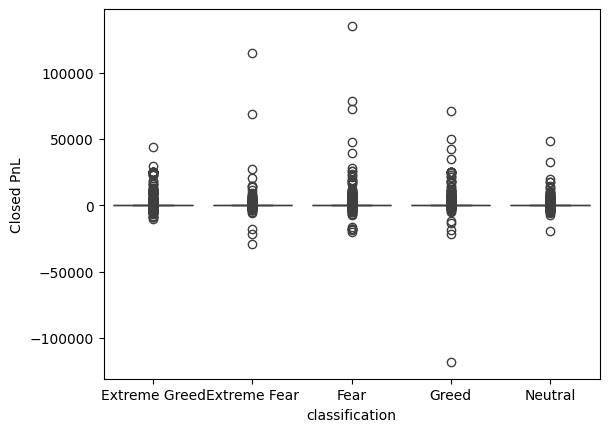

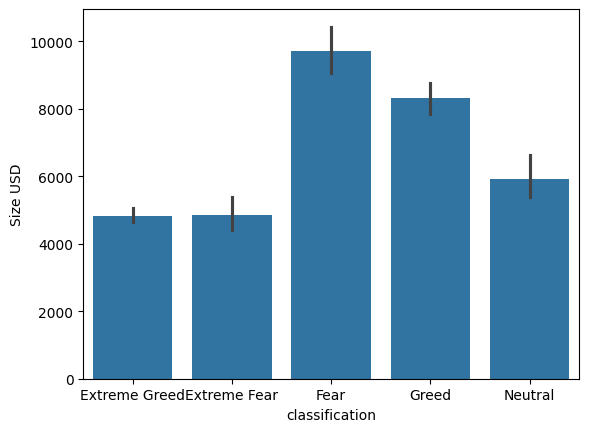

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.show()

sns.barplot(x='classification', y='Size USD', data=merged)
plt.show()

In [18]:
pnl_total = merged.groupby('Account')['Closed PnL'].sum()

winners = pnl_total[pnl_total > 0].index

merged['Trader Type'] = merged['Account'].apply(
    lambda x: 'Winner' if x in winners else 'Loser'
)

In [19]:
trade_counts = merged['Account'].value_counts()

frequent = trade_counts[trade_counts > 50].index

merged['Frequency'] = merged['Account'].apply(
    lambda x: 'Frequent' if x in frequent else 'Infrequent'
)

In [20]:
merged.shape
merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,69.493944
Extreme Greed,97.995069
Fear,73.129359
Greed,56.992051
Neutral,50.984455


In [21]:

merged['win'] = merged['Closed PnL'] > 0
merged.groupby('classification')['win'].mean()

merged.groupby('classification')['Size USD'].mean()

merged.groupby('classification').size()

,0
classification,
Extreme Fear,8244
Extreme Greed,18353
Fear,34455
Greed,28070
Neutral,22809


In [22]:

merged.groupby(['classification','Side']).size()

classification  Side
Extreme Fear    BUY      4670
                SELL     3574
Extreme Greed   BUY      8264
                SELL    10089
Fear            BUY     17343
                SELL    17112
Greed           BUY     13689
                SELL    14381
Neutral         BUY     12429
                SELL    10380
dtype: int64

In [23]:
merged.groupby(['Trader Type','classification'])['Closed PnL'].mean()

Trader Type  classification
Loser        Extreme Fear     -216.607703
             Extreme Greed     192.498023
             Fear               -1.824449
             Greed             -34.627353
             Neutral           -37.239609
Winner       Extreme Fear       78.921927
             Extreme Greed      97.158714
             Fear               73.690433
             Greed              57.326190
             Neutral            51.112282
Name: Closed PnL, dtype: float64